# Computer Vision
## Exercise Sheet 4: Greedy snake
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1.
2.
3.
4.
5.


In [20]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [21]:
import numpy as np
from numpy.linalg import norm
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In this exercise, a program framework is given. Add the missing parts for the implementation of a greedy
snake at the marked sections in the code.

* Use the gradient magnitude as image term.
* Calculate the three energy terms $E_{cont}$, $E_{curv}$, and $E_{imag}$.
* Normalize the energy terms over the neighborhood to the intervall $[0,1]$.
* Estimate the point in the neighborhood, that has minimum energy.


**Hint:** Use the following equations for the implementation of the energy terms:\\
\begin{eqnarray}
E_{cont} & = & (0.5\cdot(\|p_i-p_{i-1}\|-\|p_i-p_{i+1}\|))^2 \\
E_{curv} & = & \|p_{i-1}-2 p_i+p_{i+1}\|^2 \\
E_{imag} & = & -\|\nabla I(x,y)\|
\end{eqnarray}

Comment on the difference between using $E_{cont}$ described above and the term $(\bar d-\|p_i-p_{i-1}\|)^2$ given in the lecture.


In [22]:
def snake(img, contour, **kwargs):
    # parameter initialization
    k = contour.shape[1]
    alpha = kwargs['alpha'] * np.ones(k)
    beta = kwargs['beta'] * np.ones(k)
    gamma = kwargs['gamma'] * np.ones(k)

    # TODO: compute gradient image
    gradient_x, gradient_y = gradient(img)
    norm_image_gradient = np.sqrt(gradient_x**2 + gradient_y**2)

    k_updated = k
    iterations = 0
    # iterate until snake stops changing
    while k_updated > k * kwargs['contour_fraction']:
        iterations = iterations + 1
        k_updated = 0

        # update all contour points
        for i in range(k):
            p, updated = greedy_minimization(
                norm_image_gradient, contour, i, alpha, beta, gamma, kwargs['neighborhood_size'])
            if p is not None:
                contour[:, i] = p
            # eliminate corners if required
            if iterations > kwargs['begin_corner_elim']:
                beta = corner_elimination(contour, beta, kwargs['K_threshold'])

            # keep track of number of updated points
            if updated:
                k_updated = k_updated + 1

        # display current state of snake
        print('num_updates: {}'.format(k_updated))
        plt.imshow(norm_image_gradient)
        plt.plot(contour[1, :], contour[0, :], 'r.-')
        plt.show()

In [45]:
def greedy_minimization(norm_image_gradient, contour, i, alpha, beta, gamma, neighborhood_size):
    m, n = norm_image_gradient.shape
    k = contour.shape[1]
    # In the provided kwargs, the neighborhood size is defined as a floating point number.
    # However, to use it as a range for pixel coordinates, it should be an integer.
    w = (int(neighborhood_size) - 1) // 2
    d = average_distance(contour)
    updated = False

    # get previous, current, and next point in snake
    p_iminus1 = contour[:, wrap_index(i-1, k)]
    p_i = contour[:, i]
    p_iplus1 = contour[:, wrap_index(i+1, k)]

    # compute individual terms of energy functional
    p = []
    E_cont = []
    E_curv = []
    E_imag = []

    # Define the search range for the neighborhood
    # Note: p_i[0] is y, p_i[1] is x. m is height, n is width.
    y_range = np.arange(max(0, p_i[0] - w), min(m - 1, p_i[0] + w) + 1)
    x_range = np.arange(max(0, p_i[1] - w), min(n - 1, p_i[1] + w) + 1)

    # For all points in a local neighborhood, compute the energy terms
    for y_coord in y_range:
        for x_coord in x_range:
            # TODO: get the respective vector
            p_candidate = np.array([y_coord, x_coord])
            p.append(p_candidate)

            # TODO: compute energy terms according to lecture slides
            # Continuity term (slide 6, eq. 4)
            #(0.5⋅(∥pi−pi−1∥−∥pi−pi+1∥))2
            e_cont = (0.5 * (norm(p_candidate - p_iminus1) - norm(p_candidate - p_iplus1)))**2

            #e_cont = (d - norm(p_candidate - p_iminus1))**2
            E_cont.append(e_cont)

            # Curvature term (slide 7, eq. 6)
            e_curv = norm(p_iminus1 - 2 * p_candidate + p_iplus1)**2
            E_curv.append(e_curv)

            # Image term (slide 8, eq. 7)
            # Image is indexed (row, col) which is (y, x)
            e_imag = -(norm_image_gradient[int(y_coord), int(x_coord)]**2)
            E_imag.append(e_imag)

    if not p:
        return None, False

    # TODO: normalize individual terms of energy functional
    E_cont = np.array(E_cont)
    E_curv = np.array(E_curv)
    E_imag = np.array(E_imag)

    # Normalize to [0, 1], handling division by zero if max == min
    range_cont = E_cont.max() - E_cont.min()
    E_cont_norm = (E_cont - E_cont.min()) / range_cont if range_cont != 0 else np.zeros_like(E_cont)

    range_curv = E_curv.max() - E_curv.min()
    E_curv_norm = (E_curv - E_curv.min()) / range_curv if range_curv != 0 else np.zeros_like(E_curv)

    range_imag = E_imag.max() - E_imag.min()
    E_imag_norm = (E_imag - E_imag.min()) / range_imag if range_imag != 0 else np.zeros_like(E_imag)

    # compute energy functional and determine minimum
    E_total = alpha[i] * E_cont_norm + beta[i] * E_curv_norm + gamma[i] * E_imag_norm
    min_index = np.argmin(E_total)
    new_p_i = p[min_index]

    # determine if the current point of snake was moved
    if (p_i - new_p_i).sum() != 0:
        updated = True

    return new_p_i, updated

In [24]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y

In [25]:
def load_image_gray_normalized(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image.astype('float32')/255.

In [26]:
def wrap_index(index, k):
    if index < 0:
        index = k - 1
    elif index > k-1:
        index = 0
    return index

In [27]:
def average_distance(contour):
    avg_dist = 0
    n = contour.shape[1]

    for i in range(n-1):
        avg_dist = avg_dist+norm(contour[:, i] - contour[:, i+1])

    avg_dist = avg_dist+norm(contour[:, -1] - contour[:, 0])
    avg_dist = avg_dist / n

    return avg_dist

In [28]:
def corner_elimination(contour, beta, K_threshold):
    n = contour.shape[1]
    K = []
    # compute curvature of snake at each point
    for i in range(n):
        # get previous, current, and next point in snake
        p_iminus1 = contour[:, wrap_index(i-1, n)]
        p_i = contour[:, i]
        p_iplus1 = contour[:, wrap_index(i+1, n)]
        K.append(((p_iminus1 - 2.*p_i + p_iplus1)**2.).sum())

    # determine local maxima and set beta to zero there
    for i in range(n):
        prev_is_lower = K[wrap_index(i-1, n)] < K[i]
        next_is_lower = K[i] > K[wrap_index(i+1, n)]
        thres_exceeded = K[i] > K_threshold
        if prev_is_lower and next_is_lower and thres_exceeded:
            beta[i] = 0

    return beta

Test your implementation of the greedy snake on the provided test images. The files `ueb421.npy` and
`ueb422.npy` contain simple artificial test images. The file `ueb423.npy` contains a natural image.
Besides the test images `img`, the files contain a initialization for the snake `contour`.

You need to fit the parameter dict `kwargs` to achive good results on the different images.
**What are the relevant parameters, and what is their influence on the resulting segmentation?**

**Debug Tips**: For debugging, it makes sense to test each functionality separately. For example, set alpha and beta to zero and gamma to one. The contour-points should converge to image edges. If this is not the case, something is wrong.

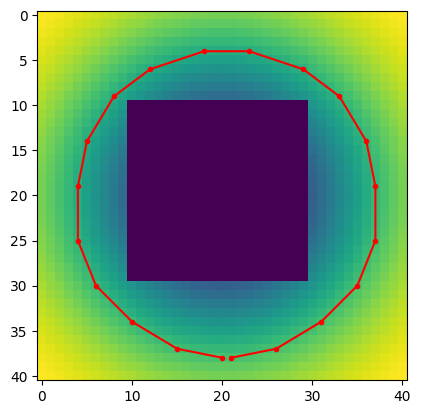

num_updates: 15


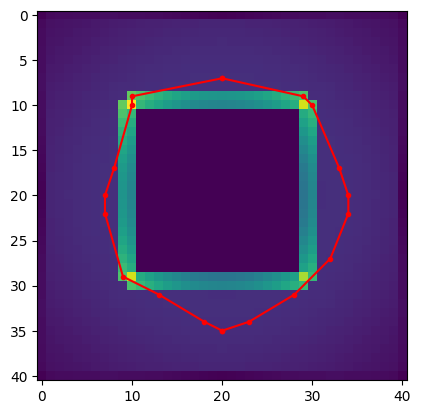

num_updates: 19


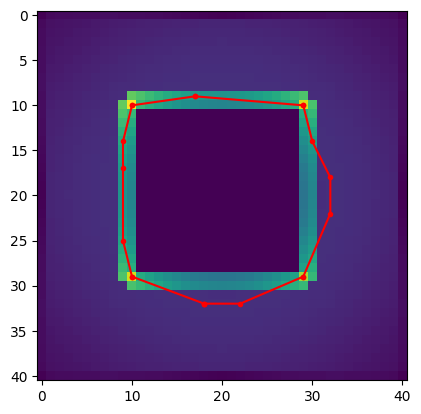

num_updates: 12


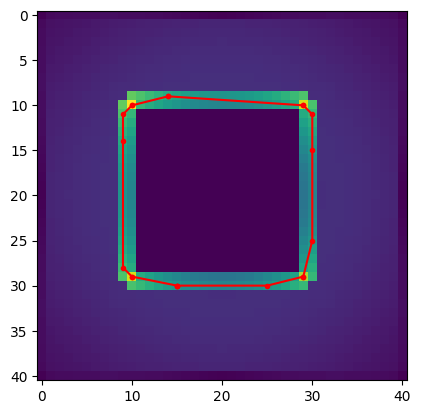

num_updates: 11


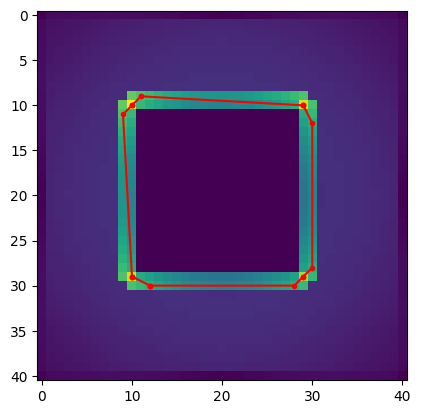

num_updates: 4


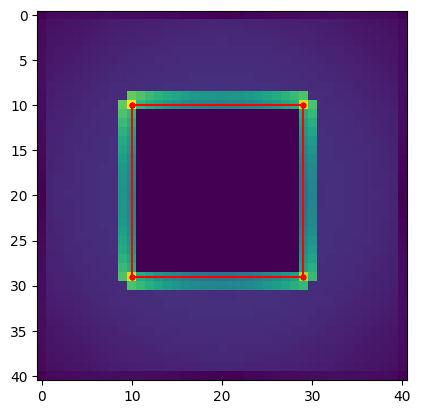

num_updates: 0


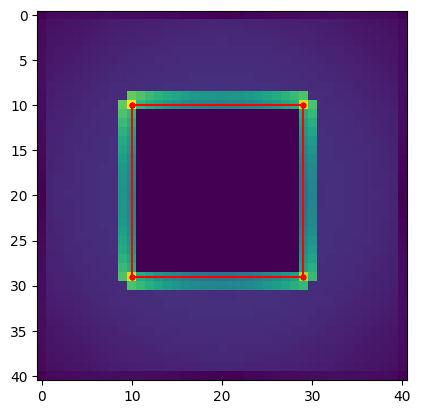

In [46]:
# load image
input_dict = np.load('data/exercise_4/ueb422.npy', allow_pickle=True).item()
image = input_dict['img']
contour = input_dict['contour']

# show initial image & contour
plt.imshow(image)
plt.plot(contour[1, :], contour[0, :], 'r.-')
plt.show()

# set keyword arguments
kwargs = {
    'neighborhood_size': 7,
    'contour_fraction': 0.1,
    'alpha': 0,
    'beta': 0,
    'gamma': 1.,
    'begin_corner_elim': 10,
    'K_threshold': 1
}

# run snake
snake(image, contour, **kwargs)

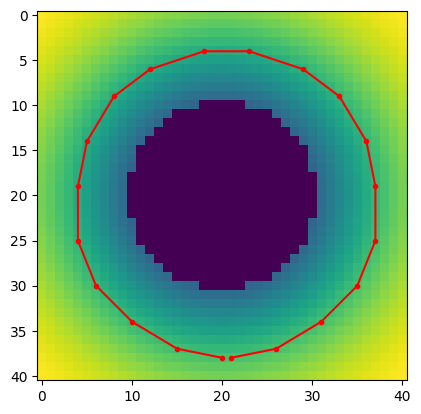

num_updates: 20


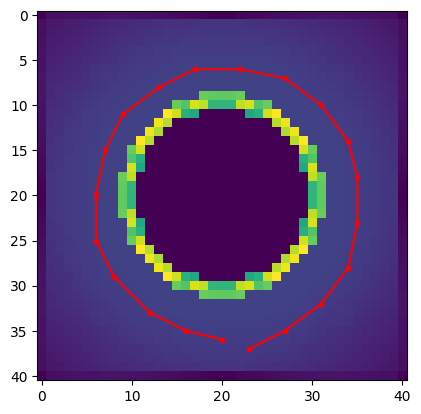

num_updates: 18


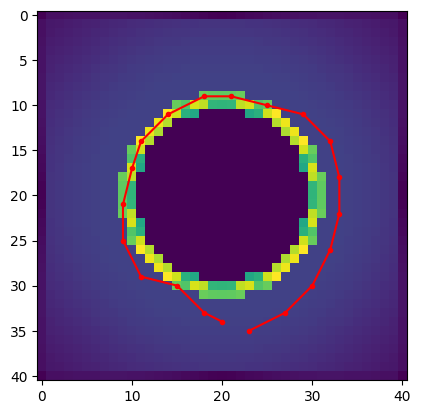

num_updates: 13


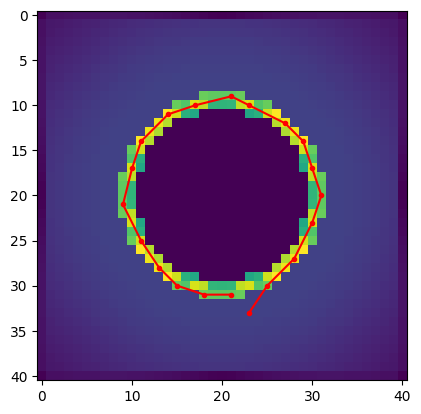

num_updates: 7


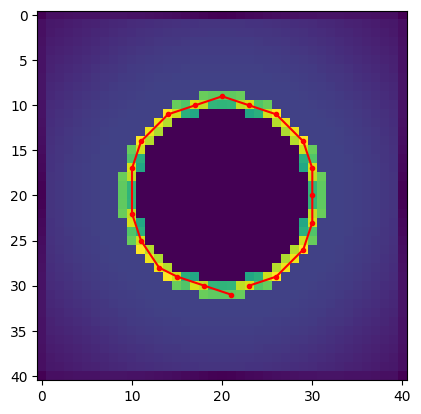

num_updates: 3


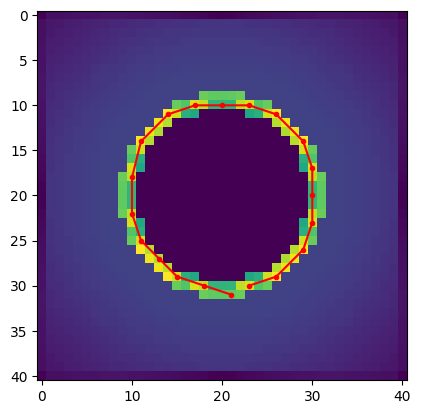

num_updates: 0


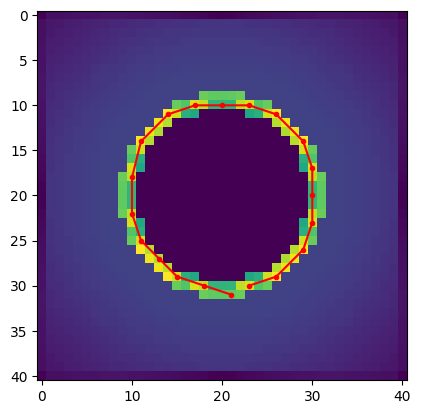

In [108]:
# load image
input_dict = np.load('data/exercise_4/ueb421.npy', allow_pickle=True).item()
image = input_dict['img']
contour = input_dict['contour']

# show initial image & contour
plt.imshow(image)
plt.plot(contour[1, :], contour[0, :], 'r.-')
plt.show()

# set keyword arguments
kwargs = {
    'neighborhood_size': 7,
    'contour_fraction': 0.1,
    'alpha': 1.0,
    'beta': 4.,
    'gamma': 1.,
    'begin_corner_elim': 10,
    'K_threshold': 1
}

# run snake
snake(image, contour, **kwargs)

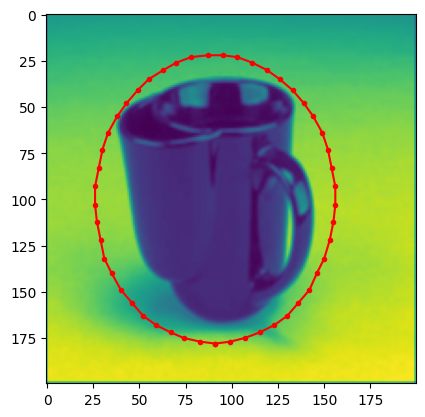

num_updates: 40


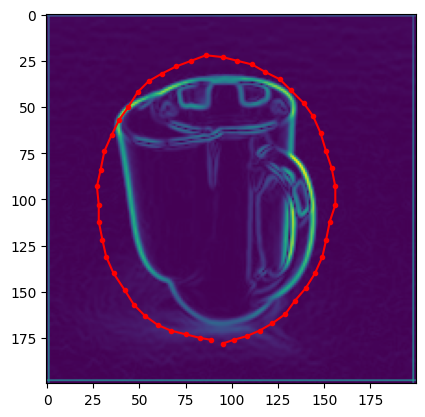

num_updates: 40


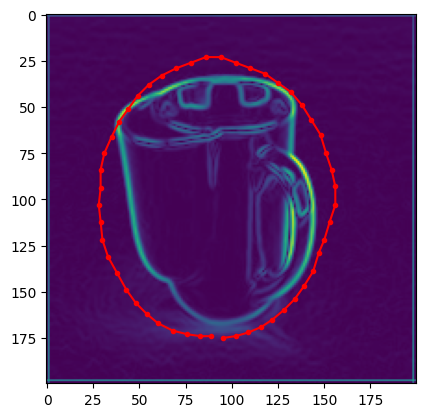

num_updates: 32


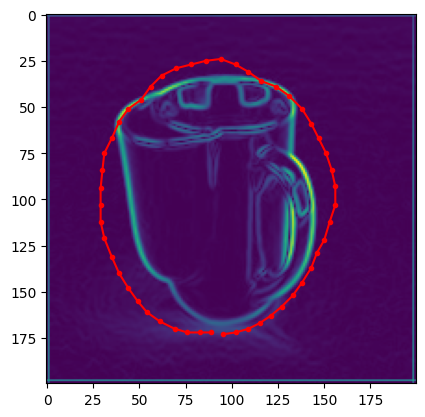

num_updates: 30


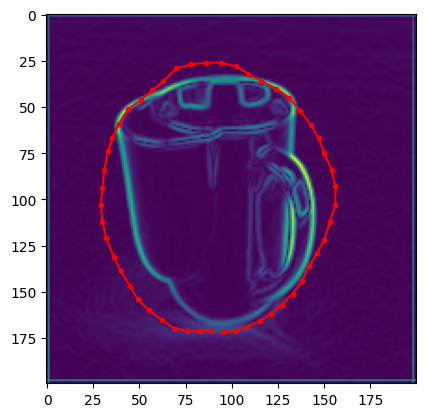

num_updates: 28


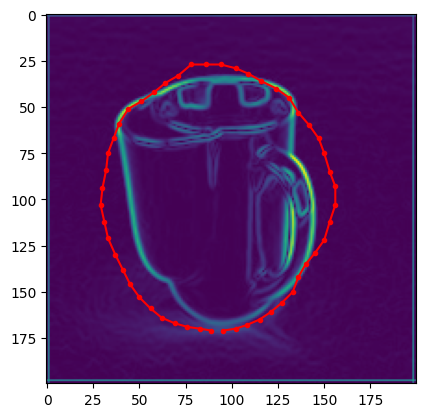

num_updates: 28


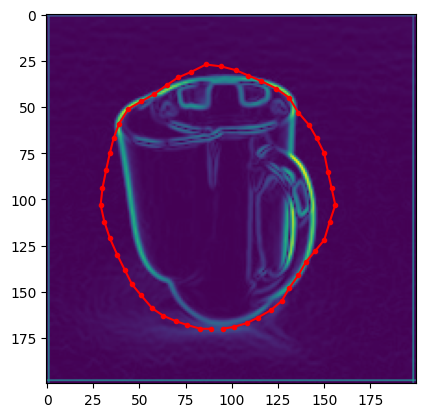

num_updates: 25


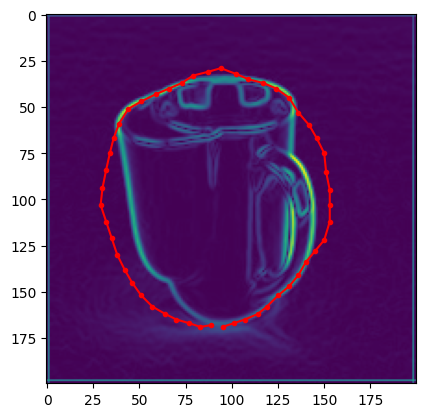

num_updates: 26


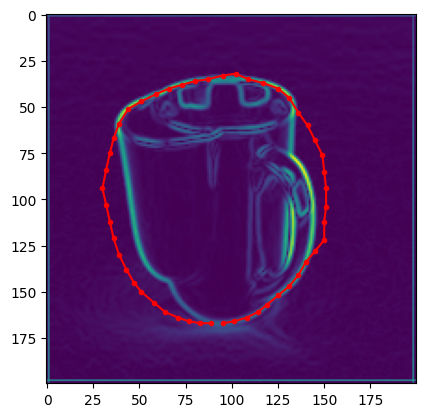

num_updates: 23


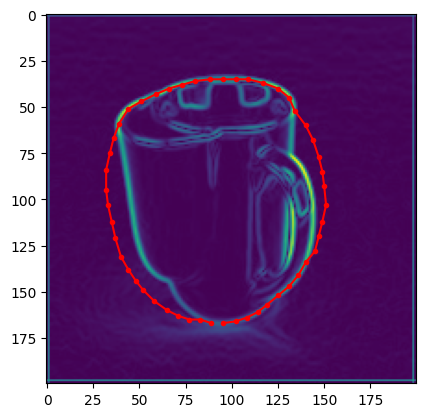

num_updates: 21


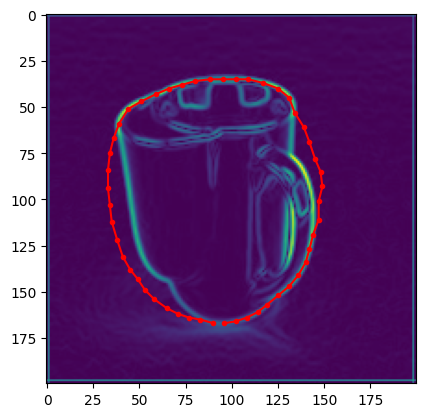

num_updates: 28


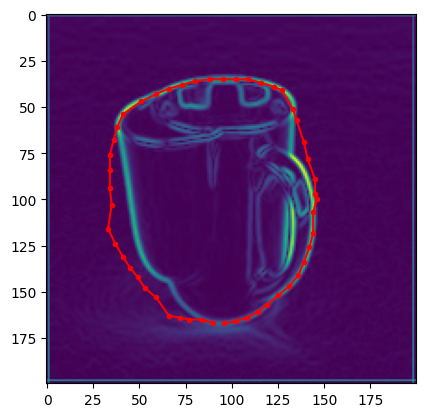

num_updates: 18


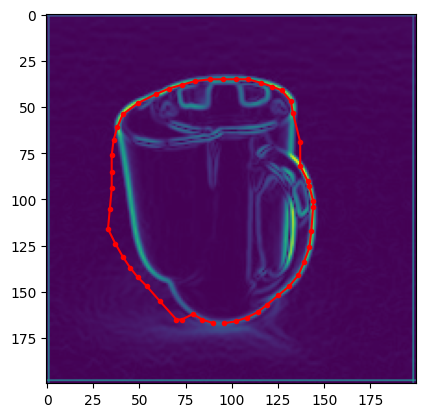

num_updates: 15


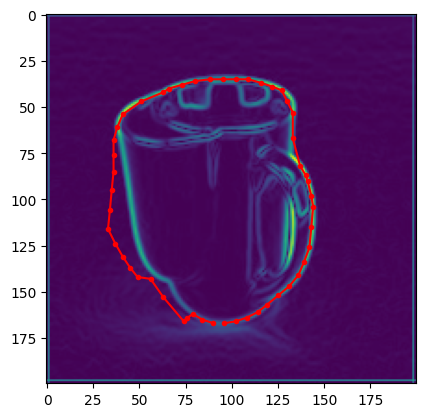

num_updates: 14


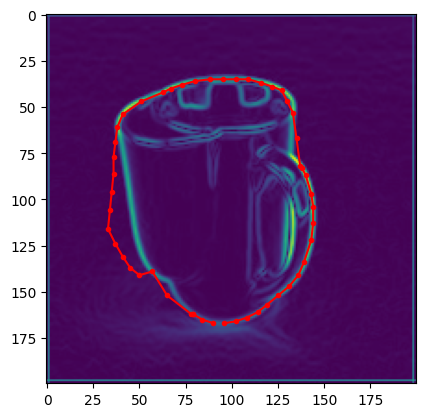

num_updates: 16


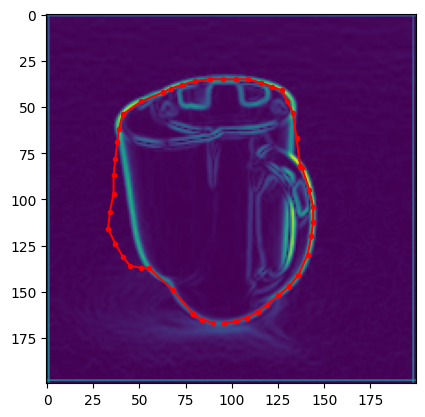

num_updates: 11


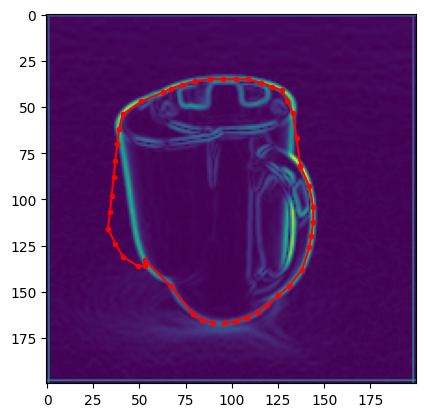

num_updates: 8


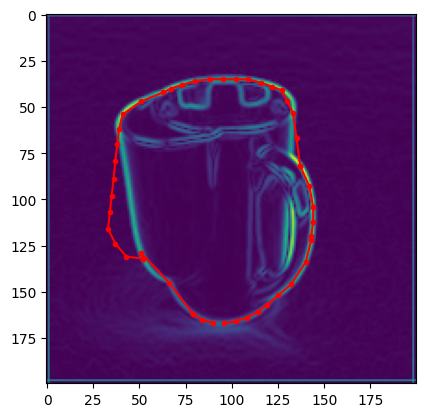

num_updates: 6


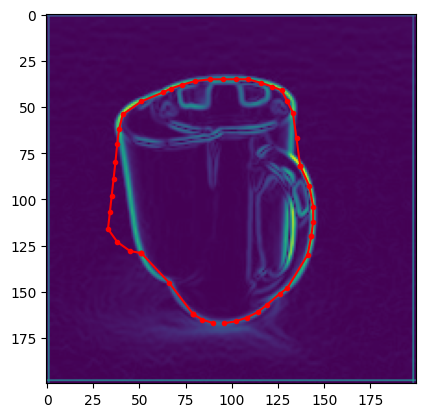

num_updates: 3


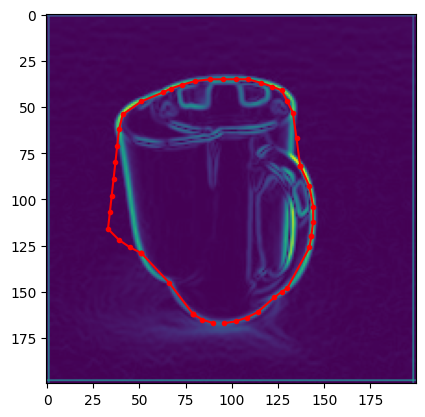

In [163]:
# load image
input_dict = np.load('data/exercise_4/ueb423.npy', allow_pickle=True).item()
image = input_dict['img']
contour = input_dict['contour']

# show initial image & contour
plt.imshow(image)
plt.plot(contour[1, :], contour[0, :], 'r.-')
plt.show()

g = 0.7
# set keyword arguments
kwargs = {
    'neighborhood_size': 10,
    'contour_fraction': 0.1,
    'alpha': 0,
    'beta': 10*g,
    'gamma': g,
    'begin_corner_elim': 10,
    'K_threshold': 5
}
# run snake
snake(image, contour, **kwargs)